## Forecasting Modeling

In [12]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
from pathlib import Path
import lightgbm as lgb
from xgboost import XGBRegressor
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.multioutput import MultiOutputRegressor

# Bảng màu trực quan hóa
GREEN = "#344f1e"
BLUE = "#2f6f9f"
RED = "#b5432f"
GRAY = "#5f6b5d"
DARK = "#111827"

In [13]:
# Set constant variables
SEED   = 42
DIR    = Path('/kaggle/input/competitions/datathon-2026-round-1/')
np.random.seed(SEED)

# Set timestamp
TRAIN_END   = pd.Timestamp('2022-12-31')
TEST_START  = pd.Timestamp('2023-01-01')
TEST_END    = pd.Timestamp('2024-07-01')

# Validation mirrors test: last 18 months of training
VAL_START   = pd.Timestamp('2021-07-01')
VAL_END     = TRAIN_END

In [14]:
# Load dataset
df_sales = pd.read_csv(DIR / 'sales.csv', parse_dates=['Date']).sort_values('Date').reset_index(drop=True)
df_promotions = pd.read_csv(DIR / 'promotions.csv', parse_dates=['start_date', 'end_date'])
df_web_traffic = pd.read_csv(DIR / 'web_traffic.csv', parse_dates=['date']).rename(columns={'date': 'Date'})
df_sample_submission = pd.read_csv(DIR / 'sample_submission.csv', parse_dates=['Date'])
df_order_items = pd.read_csv(DIR / 'order_items.csv', low_memory=False)
df_inventory = pd.read_csv(DIR / 'inventory.csv')

print(f"  Sales: {df_sales['Date'].min().date()} → {df_sales['Date'].max().date()} ({len(df_sales)} days)")
print(f"  Test : {TEST_START.date()} → {TEST_END.date()} ({len(df_sample_submission)} days)")
print(f"  Val  : {VAL_START.date()} → {VAL_END.date()} (mirrors test horizon)")

  Sales: 2012-07-04 → 2022-12-31 (3833 days)
  Test : 2023-01-01 → 2024-07-01 (548 days)
  Val  : 2021-07-01 → 2022-12-31 (mirrors test horizon)


In [15]:
# Build master daily dataframe
full_range = pd.date_range(df_sales['Date'].min(), TEST_END, freq='D')
df = pd.DataFrame({'Date': full_range})
df = df.merge(df_sales[['Date', 'Revenue', 'COGS']], on='Date', how='left')

# Promo calendar
df['has_promo'] = 0
for _, p in df_promotions.iterrows():
    m = (df['Date'] >= p['start_date']) & (df['Date'] <= p['end_date'])
    df.loc[m, 'has_promo'] = 1

df_master = df.copy().sort_values('Date').reset_index(drop=True)
print(f"Master frame: {len(df_master)} rows | NaN Revenue: {df_master['Revenue'].isna().sum()}")

Master frame: 4381 rows | NaN Revenue: 548


In [16]:
SPIKE_PERCENTILE = 95
spike_thresh = np.percentile(df_master['Revenue'].dropna(), SPIKE_PERCENTILE)
spike_mask   = df_master['Revenue'] > spike_thresh
n_spikes     = spike_mask.sum()

print(f"  Spike threshold (p{SPIKE_PERCENTILE}): {spike_thresh:,.0f}")
print(f"  Spike days in train: {n_spikes} ({n_spikes/len(df_master)*100:.1f}%)")

  Spike threshold (p95): 9,398,760
  Spike days in train: 192 (4.4%)


In [17]:
def build_features(df):
    df = df.copy()
    d  = df['Date']

    # ── Temporal
    df['month']   = d.dt.month
    df['dom']     = d.dt.day
    df['dow']     = d.dt.dayofweek
    df['doy']     = d.dt.dayofyear
    df['year']    = d.dt.year
    df['quarter'] = d.dt.quarter
    df['is_weekend']    = (df['dow'] >= 5).astype(int)
    df['is_month_end']  = (df['dom'] >= 27).astype(int)
    df['is_month_start']= (df['dom'] <= 3).astype(int)
    df['is_qtr_end']    = ((df['month'].isin([3,6,9,12])) & (df['dom'] >= 25)).astype(int)

    # Payday proximity
    dist_to_25   = np.where(df['dom'] <= 25, 25 - df['dom'], 999)
    dist_to_1    = d.dt.daysinmonth - df['dom'] + 1
    df['dist_to_payday'] = np.minimum(dist_to_25, dist_to_1)

    # ── Fourier (4 harmonics annual + 1 weekly)
    for k in [1, 2, 3, 4]:
        df[f'sin_{k}'] = np.sin(2 * np.pi * k * df['doy'] / 365.25)
        df[f'cos_{k}'] = np.cos(2 * np.pi * k * df['doy'] / 365.25)
    df['sin_w'] = np.sin(2 * np.pi * df['dow'] / 7)
    df['cos_w'] = np.cos(2 * np.pi * df['dow'] / 7)

    # ── Vietnamese events
    df['is_double_day'] = ((df['month'] == df['dom']) & (df['month'] >= 9)).astype(int)
    df['is_holiday'] = (
        ((df['dom'] == 30) & (df['month'] == 4)) | ((df['dom'] == 1) & (df['month'] == 5)) |
        ((df['dom'] == 2)  & (df['month'] == 9)) | ((df['dom'] == 1) & (df['month'] == 1)) |
        ((df['dom'] == 24) & (df['month'] == 12))
    ).astype(int)

    # Lunar New Year proximity
    tet_dates = pd.to_datetime([
        '2012-01-23','2013-02-10','2014-01-31','2015-02-19','2016-02-08',
        '2017-01-28','2018-02-16','2019-02-05','2020-01-25','2021-02-12',
        '2022-02-01','2023-01-22','2024-02-10'
    ])
    df['dist_to_tet'] = 9999
    for t in tet_dates:
        diff = (t - df['Date']).dt.days
        df['dist_to_tet'] = np.where(diff.abs() < df['dist_to_tet'].abs(), diff, df['dist_to_tet'])
    df['pre_tet_30'] = df['dist_to_tet'].between(1, 30).astype(int)
    df['is_tet']     = df['dist_to_tet'].between(-4, 2).astype(int)
    df.drop(columns=['dist_to_tet'], inplace=True)

    # ── Promo features (historical probability lookup — no look-ahead)
    train_mask = df['year'] < 2023

    promo_by_md  = (df[train_mask].groupby(['month','dom'])['has_promo']
                    .mean().reset_index().rename(columns={'has_promo':'prob_md'}))
    promo_by_dow = (df[train_mask].groupby(['dow'])['has_promo']
                    .mean().reset_index().rename(columns={'has_promo':'prob_dow'}))
    
    df = df.merge(promo_by_md, on=['month','dom'], how='left')
    df = df.merge(promo_by_dow, on=['dow'], how='left')
    df['promo_intensity'] = (df['prob_md'].fillna(0) + df['prob_dow'].fillna(0)) / 2
    df.drop(columns=['prob_md', 'prob_dow', 'has_promo'], inplace=True, errors='ignore')

    # ── SAFE LAG FEATURES — all >= 364 days, references only actual training data
    rev = df['Revenue']
    for lag in [364, 728]:
        df[f'lag_{lag}'] = rev.shift(lag)

    # Rolling windows anchored
    df['roll7_ly']  = df['lag_364'].rolling(7,  min_periods=1).mean()
    df['roll28_ly'] = df['lag_364'].rolling(28, min_periods=1).mean()
    
    df['roll7_2y']  = df['lag_728'].rolling(7,  min_periods=1).mean()
    df['roll28_2y'] = df['lag_728'].rolling(28, min_periods=1).mean()

    # YoY Momentum
    df['yoy_ratio']    = df['lag_364'] / (df['lag_728'] + 1e-9)
    df['roll28_ratio'] = df['roll28_ly'] / (df['roll28_2y'] + 1e-9)

    return df

print("Building features...")
df = build_features(df_master)

EXCLUDE   = {'Date', 'Revenue', 'COGS', 'has_promo', 'sessions', 'year'}
FEAT_COLS = list(dict.fromkeys(
    [c for c in df.columns if c not in EXCLUDE and df[c].dtype in [float, np.float64, int, np.int64, np.int32]]
))

print(f"Feature columns  : {len(FEAT_COLS)}")
print(f"NaN in test features: {df.loc[df['Date'].between(TEST_START,TEST_END), FEAT_COLS].isna().sum().sum()}")
df.to_csv('df_features.csv', index=False)

Building features...
Feature columns  : 33
NaN in test features: 860


## XGBoost Model & Forecasting
Tiến hành chia tập Train/Test và huấn luyện mô hình XGBoost trực tiếp trên các đặc trưng thời gian, lag và chu kỳ đã trích xuất. Trực quan hóa kết quả để so sánh với tập huấn luyện.

Multimodal 

In [18]:
# split data
train_mask = df['Date'] <= TRAIN_END
test_mask  = (df['Date'] >= TEST_START) & (df['Date'] <= TEST_END)

X_train = df.loc[train_mask, FEAT_COLS]
y_train = df.loc[train_mask, ['Revenue', 'COGS']]
X_test  = df.loc[test_mask, FEAT_COLS]

base_model = XGBRegressor(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.03,
    subsample=0.9,
    colsample_bytree=0.9,
    objective="reg:squarederror",
    random_state=SEED
)

model = MultiOutputRegressor(base_model)
model.fit(X_train, y_train)

preds = model.predict(X_test)

rev_pred  = preds[:, 0]
cogs_pred = preds[:, 1]

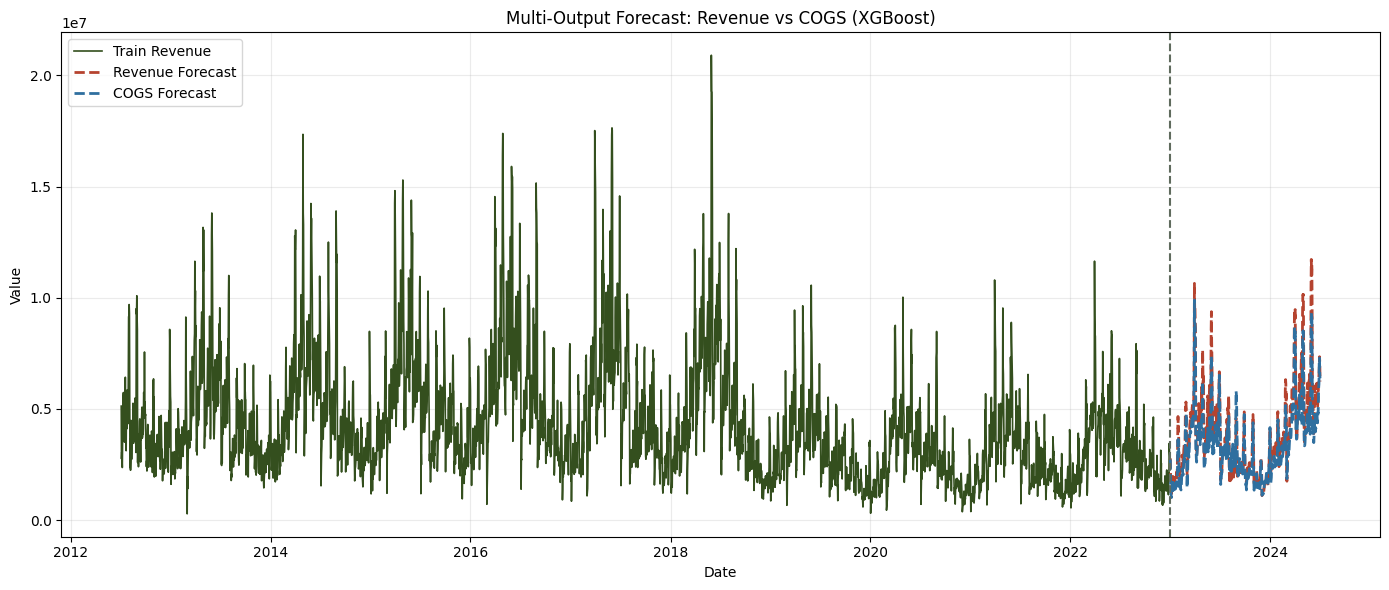

In [19]:
# =========================
# 1. Predict
# =========================
preds = model.predict(X_test)

rev_pred  = preds[:, 0]
cogs_pred = preds[:, 1]

# =========================
# 2. Post-process constraints
# =========================
rev_pred  = np.maximum(0, rev_pred)
cogs_pred = np.maximum(0, cogs_pred)

# # COGS không vượt Revenue
# cogs_pred = np.minimum(cogs_pred, rev_pred)

# =========================
# 3. Build test dataframe
# =========================
df_test = df.loc[test_mask].copy()
df_test['Revenue_Pred'] = rev_pred
df_test['COGS_Pred']    = cogs_pred

# =========================
# 4. Visualization
# =========================
plt.figure(figsize=(14, 6))

# Revenue
plt.plot(
    df.loc[train_mask, 'Date'],
    df.loc[train_mask, 'Revenue'],
    label="Train Revenue",
    color=GREEN,
    linewidth=1.2
)

plt.plot(
    df_test['Date'],
    df_test['Revenue_Pred'],
    label="Revenue Forecast",
    color=RED,
    linestyle="--",
    linewidth=2.0
)

# COGS (thêm line mới)
plt.plot(
    df_test['Date'],
    df_test['COGS_Pred'],
    label="COGS Forecast",
    color=BLUE,
    linestyle="--",
    linewidth=2.0
)

# Split line
plt.axvline(TEST_START, color=GRAY, linestyle="--", linewidth=1.5)

plt.title("Multi-Output Forecast: Revenue vs COGS (XGBoost)")
plt.xlabel("Date")
plt.ylabel("Value")
plt.legend(loc="upper left", frameon=True)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

In [20]:
df_sub = df.loc[test_mask, ['Date']].copy()

df_sub['Revenue'] = rev_pred
df_sub['COGS']    = cogs_pred

df_sub.to_csv('submission.csv', index=False)
display(df_sub.head())
print("Saved submission.csv")

,Date,Revenue,COGS
3833,2023-01-01,2775001.500,2.723832e+06
3834,2023-01-02,1997742.875,1.670401e+06
3835,2023-01-03,1847668.500,1.375840e+06
3836,2023-01-04,1479689.625,1.110710e+06
3837,2023-01-05,1178823.375,1.008039e+06


Saved submission.csv


In [21]:
print("Mean Revenue:", df_sub['Revenue'].mean())
print("Std Revenue:", df_sub['Revenue'].std())
print("Max Revenue:", df_sub['Revenue'].max())

Mean Revenue: 3839045.2
Std Revenue: 1918719.125
Max Revenue: 11722178.0
